# E-Commerce Funnel Analysis

## Project Objective

The objective of this project is to analyze user behavior across the e-commerce purchase funnel. By tracking user progression through the View → Cart → Purchase stages, this analysis identifies conversion rates, drop-off points, and customer behavior patterns to uncover opportunities for improving overall sales performance.

## Dataset Description

**Dataset:** Kaggle E-Commerce Behavior Dataset (October 2019)

The dataset contains customer interaction events collected from a multi-category online store.

### Funnel Stages

* **View:** User viewed a product.
* **Cart:** User added a product to the shopping cart.
* **Purchase:** User completed a purchase.

## Analysis Workflow

1. Data Loading
2. Data Cleaning & Preprocessing
3. Session-Level Funnel Construction
4. Overall Funnel Analysis
5. User-Level Funnel Analysis
6. Brand Analysis
7. Category Analysis
8. Time-Based Analysis
9. KPI Analysis
10. Business Insights & Recommendations


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("done")

done


In [6]:
df = pd.read_csv(r'/Users/aryan/Downloads/archive (5)/2019-Oct.csv')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


# Data Preparation

In [41]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [8]:
df.shape

(42448764, 9)

In [23]:
type(df)

pandas.core.frame.DataFrame

In [10]:
df.tail()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
42448759,2019-10-31 23:59:58 UTC,view,2300275,2053013560530830019,electronics.camera.video,gopro,527.40,537931532,22c57267-da98-4f28-9a9c-18bb5b385193
42448760,2019-10-31 23:59:58 UTC,view,10800172,2053013554994348409,NaN,redmond,61.75,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8
42448761,2019-10-31 23:59:58 UTC,view,5701038,2053013553970938175,auto.accessories.player,kenwood,128.70,566280422,05b6c62b-992f-4e8e-91f7-961bcb4719cd
42448762,2019-10-31 23:59:59 UTC,view,21407424,2053013561579406073,electronics.clocks,tissot,689.85,513118352,4c14bf2a-2820-4504-929d-046356a5a204
42448763,2019-10-31 23:59:59 UTC,view,13300120,2053013557166998015,NaN,swisshome,155.73,525266378,6e57d2d7-6022-46e6-81d6-fa77f14cefd8


In [22]:
df.sample(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
14101829,2019-10-11 17:22:43 UTC,view,43800006,2100064858975240628,furniture.kitchen.table,ersport,115.83,552784549,03deaa4d-b84d-473c-a3db-3c8b37a1f4d1
38034394,2019-10-28 10:40:42 UTC,view,4201085,2053013552351936731,appliances.environment.air_conditioner,electrolux,244.51,542870071,97b09185-9428-4b26-a9e1-6d28748800f9
15941386,2019-10-13 04:14:06 UTC,view,1004589,2053013555631882655,electronics.smartphone,inoi,58.96,513321287,fae51b5a-68d8-4abd-b862-086d0128920a
26480741,2019-10-20 04:39:43 UTC,purchase,1004833,2053013555631882655,electronics.smartphone,samsung,172.06,525454715,c8deca0c-a942-4f45-9531-128cebb08d59
4428784,2019-10-04 13:48:46 UTC,view,28101059,2053013564918072245,NaN,nikotex,115.58,522158321,cca53b1e-840a-4b07-8f40-26ffb52a9383


In [18]:
print(df.columns)

print("total no of cols: ",df.columns.nunique())

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')
total no of cols:  9


In [24]:
df.dtypes

event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object

In [27]:
df['event_time'] = pd.to_datetime(df['event_time'])
print(df.dtypes)

event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
dtype: object


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 2.8+ GB


In [30]:
df.isna().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

In [39]:
# Looking at imp info about dataset numeric cols

df_desc = df.describe().style.format('{:,.2f}')
df_desc

,product_id,category_id,price,user_id
count,"42,448,764.00","42,448,764.00","42,448,764.00","42,448,764.00"
mean,"10,549,932.38","2,057,404,237,940,798,720.00",290.32,"533,537,147.51"
std,"11,881,906.97","18,439,264,662,054,096.00",358.27,"18,523,738.17"
min,"1,000,978.00","2,053,013,552,226,107,648.00",0.00,"33,869,381.00"
25%,"1,005,157.00","2,053,013,555,464,110,592.00",65.98,"515,904,318.00"
50%,"5,000,470.00","2,053,013,555,631,882,752.00",162.93,"529,696,452.00"
75%,"16,000,305.00","2,053,013,563,424,899,840.00",358.57,"551,578,838.25"
max,"60,500,010.00","2,175,419,595,093,967,616.00","2,574.07","566,280,860.00"


In [40]:
# Looking at imp info about all cols

df.describe(include = 'object')

,event_type,category_code,brand,user_session
count,42448764,28933155,36331684,42448762
unique,3,126,3444,9244421
top,view,electronics.smartphone,samsung,fb075266-182d-4c11-b5f7-4e4dcdabd4a7
freq,40779399,11507231,5282775,1159


# Data Cleaning and Preprocessing


In [42]:
# Checking for null values
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64


In [44]:
# Checking for duplicate values
print(df.duplicated().sum())

30220


In [47]:
# Dropping the duplicates
df.drop_duplicates(inplace = True)
print(df.duplicated().sum())

0


In [45]:
# Checking for total unique values
df.nunique()

event_time       2621538
event_type             3
product_id        166794
category_id          624
category_code        126
brand               3444
price              65298
user_id          3022290
user_session     9244421
dtype: int64

In [51]:
# Creating cols for date, day of week , hour, weeknumber 

df['date'] = df['event_time'].dt.date
df['day_of_week'] = df['event_time'].dt.day_name()

In [56]:
df['hour'] = df['event_time'].dt.hour
df['week_num'] = df['event_time'].dt.isocalendar().week

In [117]:
# Now we will look how many events did a particualr user did.

df['event_sequence'] = df.groupby('user_session').cumcount()+1

In [63]:
# Basic insights

print("total user ids: ", df['user_id'].nunique())
print("total session ids: ", df['user_session'].nunique())
print("date range: ",df['date'].min() , " to ", df['date'].max())

total user ids:  3022290
total session ids:  9244421
date range:  2019-10-01  to  2019-10-31


# Building the Session-Level Funnel

We are creating a Sales-level Funnel.

"How do individual browsing sessions convert?"

In [71]:
# Just to know the different types of "event_types"

df.groupby('event_type')['user_id'].count()

event_type
cart          898443
purchase      742773
view        40777328
Name: user_id, dtype: int64

In [106]:
# Defining funnel stages in order

funnel_stages = ['view','cart','purchase']

df = df.sort_values(['user_session','event_time'])

# We can see one thing that in df, if the user views something, then also there is a price val for the row.
# So we cant use the price col in our sesion summary. We need a new col in df named 'revenue'

df['revenue'] = np.where(df['event_type'] == 'purchase' , df['price'], 0)

session_summary = df.groupby("user_session").agg({"user_id" : "first" , "event_time" : ['min','max'], 
                                                  "event_type" : list, 'revenue': 'sum'}).reset_index()
session_summary.head()

user_session    user_id                event_time  \
                                             first                       min   
0  00000042-3e3f-42f9-810d-f3d264139c50  515483062 2019-10-18 10:54:45+00:00   
1  00000056-a206-40dd-b174-a072550fa38c  513782162 2019-10-31 06:23:12+00:00   
2  00000083-8816-4d58-a9b8-f52f54186edc  546521725 2019-10-06 11:24:45+00:00   
3  000001fd-1f89-45e8-a3ce-fe3218cabfad  560486342 2019-10-25 08:30:42+00:00   
4  000003eb-b63e-45d9-9f26-f229057c654a  512483064 2019-10-03 11:28:52+00:00   

                             \
                        max   
0 2019-10-18 10:55:20+00:00   
1 2019-10-31 06:31:25+00:00   
2 2019-10-06 11:34:30+00:00   
3 2019-10-25 08:39:11+00:00   
4 2019-10-03 11:28:52+00:00   

                                          event_type revenue  
                                                list     sum  
0                                       [view, view]    0.00  
1   [view, view, view, view, view, view, view, view]    0.00  
2  [view, view, view, view, view, view, view, vie...  289.52  
3  [view, view, view, view, cart, view, cart, car...  171.90  
4                                             [view]    0.00

In [107]:
# Flatten col names

session_summary.columns = ['user_session',"user_id","session_start","session_end","event_type","price"]

In [135]:
# Calculate session duration in seconds since it is easier to interpret

session_summary["session_duration_sec"] = (session_summary["session_end"] - session_summary["session_start"]).dt.total_seconds()
session_summary.head()

,user_session,user_id,session_start,session_end,event_type,price,session_duration_min,max_funnel_stage,session_duration_sec
0,00000042-3e3f-42f9-810d-f3d264139c50,515483062,2019-10-18 10:54:45+00:00,2019-10-18 10:55:20+00:00,"[view, view]",0.00,35.0,view,35.0
1,00000056-a206-40dd-b174-a072550fa38c,513782162,2019-10-31 06:23:12+00:00,2019-10-31 06:31:25+00:00,"[view, view, view, view, view, view, view, view]",0.00,493.0,view,493.0
2,00000083-8816-4d58-a9b8-f52f54186edc,546521725,2019-10-06 11:24:45+00:00,2019-10-06 11:34:30+00:00,"[view, view, view, view, view, view, view, vie...",289.52,585.0,purchase,585.0
3,000001fd-1f89-45e8-a3ce-fe3218cabfad,560486342,2019-10-25 08:30:42+00:00,2019-10-25 08:39:11+00:00,"[view, view, view, view, cart, view, cart, car...",171.90,509.0,purchase,509.0
4,000003eb-b63e-45d9-9f26-f229057c654a,512483064,2019-10-03 11:28:52+00:00,2019-10-03 11:28:52+00:00,[view],0.00,0.0,view,0.0


In [109]:
# Creating a function to check the max funnel stage reached
# We have already build the funnel_stages list

def get_max_funnel_stage(events):
    if 'purchase' in events:
        return 'purchase'
    elif 'cart' in events:
        return 'cart'
    else:
        return 'view'

# Now we create a new col max_funnel_stage in session_summary

session_summary['max_funnel_stage'] = session_summary['event_type'].apply(get_max_funnel_stage)
session_summary[['event_type','max_funnel_stage']].head()

,event_type,max_funnel_stage
0,"[view, view]",view
1,"[view, view, view, view, view, view, view, view]",view
2,"[view, view, view, view, view, view, view, vie...",purchase
3,"[view, view, view, view, cart, view, cart, car...",purchase
4,[view],view


# Overall Funnel Analysis

In [110]:
# Now we want to count sessions that reached a max particular stage

funnel_df = pd.DataFrame({"Stage": ["view","cart","purchse"], 
                         "sessions" : [len(session_summary),
                                        session_summary['event_type'].apply(lambda x : 'cart' in x).sum(),
                                        session_summary['event_type'].apply(lambda x : 'purchase' in x).sum()]
                         })
funnel_df

,Stage,sessions
0,view,9244421
1,cart,573097
2,purchse,629560


### Funnel Anomaly:

Purchase sessions (629,560) exceed cart sessions (573,097),
which is counterintuitive for a standard e-commerce funnel.

This suggests that a significant number of users may be completing
purchases without a recorded cart interaction. Possible explanations include:
1. Direct "Buy Now" purchases
2. Cart and purchase occurring in different sessions
3. Missing or incomplete cart event tracking

Next, we'll quantify how many sessions contain a purchase event
without any corresponding cart event.

In [111]:
purchase_without_cart = session_summary[
    session_summary['event_type'].apply(lambda x: ('purchase' in x) and ('cart' not in x)
    )
]

In [112]:
# Calculating Conversion Rates

# Conversion Rate (relative to View stage)
funnel_df['conversion_rate'] = funnel_df['sessions'] *100/ funnel_df['sessions'].iloc[0]

# Drop-off Rate (relative to previous stage)
# Since we are calculating drop off rate , we will do 1 - {}
# other wise it will give us the retention rate

funnel_df['drop_off_rate'] = (1 - (funnel_df['sessions']/funnel_df['sessions'].shift(1)))*100

# First row has no previous stage
funnel_df.loc[0,'drop_off_rate'] = 0

funnel_df

,Stage,sessions,conversion_rate,drop_off_rate
0,view,9244421,100.000000,0.000000
1,cart,573097,6.199382,93.800618
2,purchse,629560,6.810162,-9.852259


### Funnel Observation

The drop-off rate between Cart and Purchase is negative (-9.85%).

In a traditional e-commerce funnel, the number of purchase sessions should be lower than the number of cart sessions. However, our analysis shows the opposite.

Further investigation revealed that 337,699 purchase sessions contained no cart event. This suggests that users may be completing purchases through alternative flows, purchasing in a different session than the cart event, or that cart interactions are not consistently tracked.

In [136]:
session_summary.head()

,user_session,user_id,session_start,session_end,event_type,price,session_duration_min,max_funnel_stage,session_duration_sec
0,00000042-3e3f-42f9-810d-f3d264139c50,515483062,2019-10-18 10:54:45+00:00,2019-10-18 10:55:20+00:00,"[view, view]",0.00,35.0,view,35.0
1,00000056-a206-40dd-b174-a072550fa38c,513782162,2019-10-31 06:23:12+00:00,2019-10-31 06:31:25+00:00,"[view, view, view, view, view, view, view, view]",0.00,493.0,view,493.0
2,00000083-8816-4d58-a9b8-f52f54186edc,546521725,2019-10-06 11:24:45+00:00,2019-10-06 11:34:30+00:00,"[view, view, view, view, view, view, view, vie...",289.52,585.0,purchase,585.0
3,000001fd-1f89-45e8-a3ce-fe3218cabfad,560486342,2019-10-25 08:30:42+00:00,2019-10-25 08:39:11+00:00,"[view, view, view, view, cart, view, cart, car...",171.90,509.0,purchase,509.0
4,000003eb-b63e-45d9-9f26-f229057c654a,512483064,2019-10-03 11:28:52+00:00,2019-10-03 11:28:52+00:00,[view],0.00,0.0,view,0.0


In [130]:
revenue_stats = session_summary[session_summary['max_funnel_stage'] == 'purchase']['price'].agg(['sum','mean','count'])

print(f"Total Revenue: ${revenue_stats['sum']:,.2f}")
print(f"Avg order val: ${revenue_stats['mean']:,.2f}")
print(f"Total orders: {int(revenue_stats['count']):,}")

Total Revenue: $229,933,212.63
Avg order val: $365.23
Total orders: 629,560


# Visualization - Overall Funnel

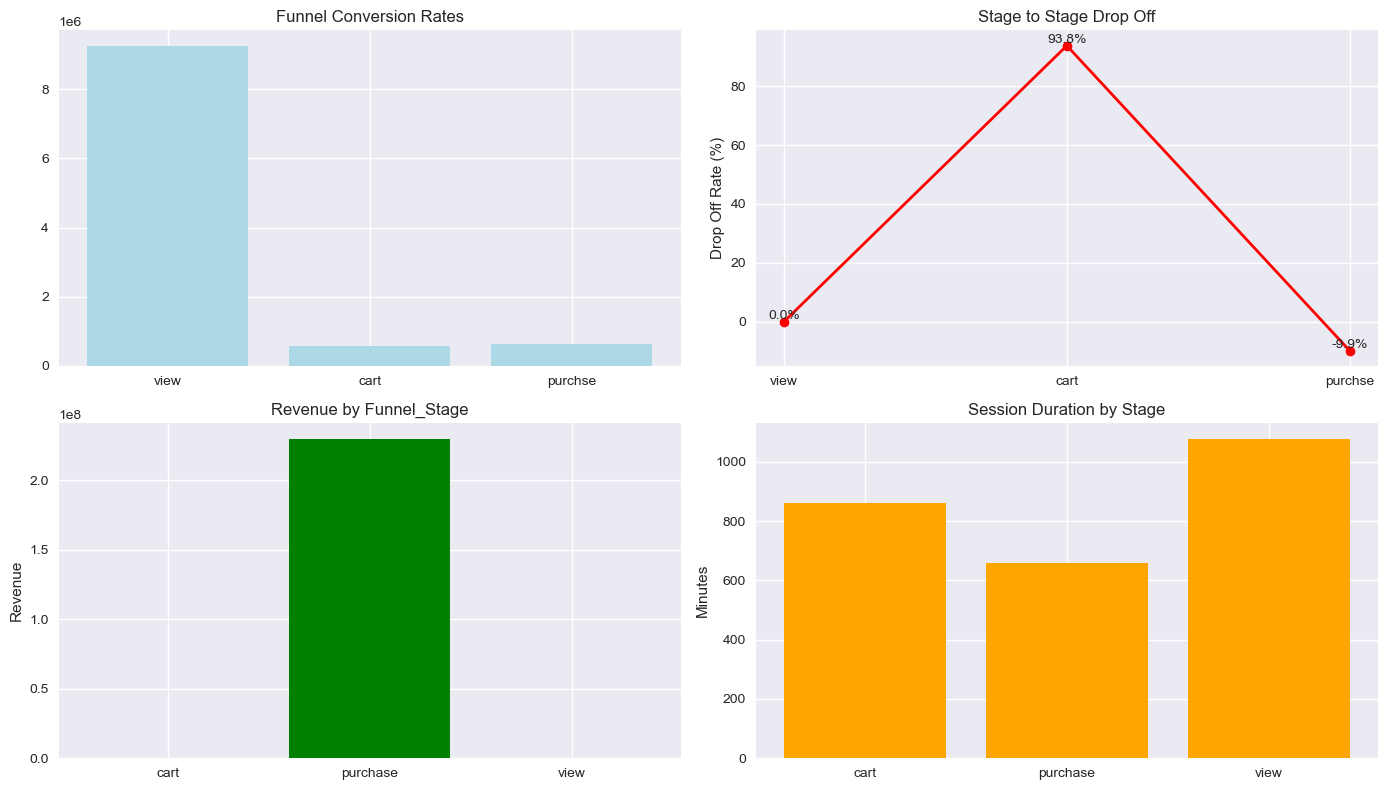

In [156]:
# Funnel conversion Rates
plt.figure(figsize = (14,8))
plt.subplot(2,2,1)
plt.bar(funnel_df['Stage'], funnel_df['sessions'],color = 'lightblue')
plt.title('Funnel Conversion Rates')

# Drop-off Rates
plt.subplot(2,2,2)
plt.plot(funnel_df['Stage'],funnel_df['drop_off_rate'],color = 'red', marker = 'o', linewidth = 2)
for x, y in zip(funnel_df['Stage'], funnel_df['drop_off_rate']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.title('Stage to Stage Drop Off')
plt.ylabel('Drop Off Rate (%)')

# Revenue by stage
rev_by_stage = session_summary.groupby('max_funnel_stage')['price'].sum().reset_index()
plt.subplot(2,2,3)
plt.bar(rev_by_stage['max_funnel_stage'], rev_by_stage['price'], color = 'green')
plt.title('Revenue by Funnel_Stage')
plt.ylabel('Revenue')

# Session duration by stage
duration_by_stage = session_summary.groupby('max_funnel_stage')['session_duration_sec'].mean().reset_index()
plt.subplot(2,2,4)
plt.bar(duration_by_stage['max_funnel_stage'],duration_by_stage['session_duration_sec'],color = 'orange')
plt.title('Session Duration by Stage')
plt.ylabel('Minutes')
plt.tight_layout()


# User-Level Funnel Analysis

In [150]:
df2 = df.sort_values(['user_id','event_time'])


session_summary_user = df2.groupby("user_id").agg({"event_time" : ['min','max'], 
                                                  "event_type" : list, 'revenue': 'sum'}).reset_index()
session_summary_user.head()

user_id                event_time                            \
                                   min                       max   
0   33869381 2019-10-23 20:04:08+00:00 2019-10-23 20:04:08+00:00   
1   64078358 2019-10-13 00:13:46+00:00 2019-10-13 00:13:46+00:00   
2  183503497 2019-10-02 21:43:00+00:00 2019-10-02 21:43:00+00:00   
3  184265397 2019-10-04 17:44:37+00:00 2019-10-15 17:19:28+00:00   
4  195082191 2019-10-10 03:35:36+00:00 2019-10-10 03:35:36+00:00   

                             event_type revenue  
                                   list     sum  
0                                [view]     0.0  
1                                [view]     0.0  
2                                [view]     0.0  
3  [view, view, view, view, view, view]     0.0  
4                                [view]     0.0

In [151]:
# Flatten col names

session_summary_user.columns = ['user_id',"session_start","session_end","event_type","price"]

In [152]:
# Calculating session duration in seconds since it is easier to interpret

session_summary_user["session_duration_sec"] = (session_summary_user["session_end"] - session_summary_user["session_start"]).dt.total_seconds()
session_summary_user.head()

,user_id,session_start,session_end,event_type,price,session_duration_sec
0,33869381,2019-10-23 20:04:08+00:00,2019-10-23 20:04:08+00:00,[view],0.0,0.0
1,64078358,2019-10-13 00:13:46+00:00,2019-10-13 00:13:46+00:00,[view],0.0,0.0
2,183503497,2019-10-02 21:43:00+00:00,2019-10-02 21:43:00+00:00,[view],0.0,0.0
3,184265397,2019-10-04 17:44:37+00:00,2019-10-15 17:19:28+00:00,"[view, view, view, view, view, view]",0.0,948891.0
4,195082191,2019-10-10 03:35:36+00:00,2019-10-10 03:35:36+00:00,[view],0.0,0.0


In [154]:
# Creating a function to check the max funnel stage reached
# We have already build the funnel_stages list

def get_max_funnel_stage_user(events):
    if 'purchase' in events:
        return 'purchase'
    elif 'cart' in events:
        return 'cart'
    else:
        return 'view'

# Now we create a new col max_funnel_stage in session_summary

session_summary_user['max_funnel_stage'] = session_summary_user['event_type'].apply(get_max_funnel_stage_user)
session_summary_user[['event_type','max_funnel_stage']].head()

,event_type,max_funnel_stage
0,[view],view
1,[view],view
2,[view],view
3,"[view, view, view, view, view, view]",view
4,[view],view


# Overall User Funnel Analysis 

In [157]:
# Now we want to count sessions that reached a max particular stage

funnel_df_user = pd.DataFrame({"Stage": ["view","cart","purchse"], 
                         "sessions" : [len(session_summary_user),
                                        session_summary_user['event_type'].apply(lambda x : 'cart' in x).sum(),
                                        session_summary_user['event_type'].apply(lambda x : 'purchase' in x).sum()]
                         })
funnel_df_user

,Stage,sessions
0,view,3022290
1,cart,337117
2,purchse,347118


In [158]:
# Calculating Conversion Rates

# Conversion Rate (relative to View stage)
funnel_df_user['conversion_rate'] = funnel_df_user['sessions'] *100/ funnel_df_user['sessions'].iloc[0]

# Drop-off Rate (relative to previous stage)
# since we are calculating drop off rate , we will do 1 - {}
# Other wise it will give us the retention rate

funnel_df_user['drop_off_rate'] = (1 - (funnel_df_user['sessions']/funnel_df_user['sessions'].shift(1)))*100

# First row has no previous stage
funnel_df_user.loc[0,'drop_off_rate'] = 0

funnel_df_user

,Stage,sessions,conversion_rate,drop_off_rate
0,view,3022290,100.000000,0.000000
1,cart,337117,11.154356,88.845644
2,purchse,347118,11.485264,-2.966626


In [159]:
revenue_stats_user = session_summary_user[session_summary_user['max_funnel_stage'] == 'purchase']['price'].agg(['sum','mean','count'])

print(f"Total Revenue: ${revenue_stats_user['sum']:,.2f}")
print(f"Avg order val: ${revenue_stats_user['mean']:,.2f}")
print(f"Total orders: {int(revenue_stats_user['count']):,}")

Total Revenue: $229,933,212.63
Avg order val: $662.41
Total orders: 347,118


# Visualization - Overall Funnel

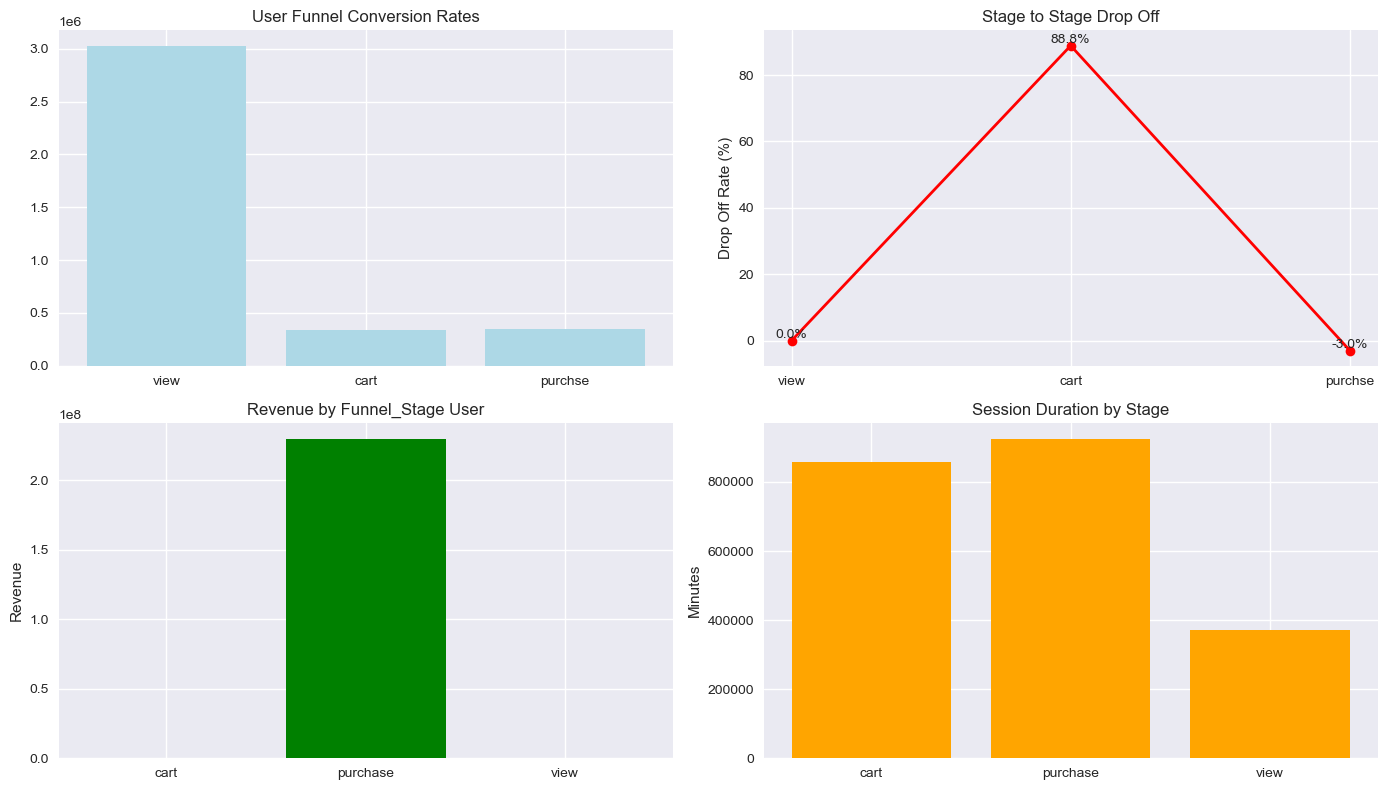

In [164]:
# Funnel conversion Rates
plt.figure(figsize = (14,8))
plt.subplot(2,2,1)
plt.bar(funnel_df_user['Stage'], funnel_df_user['sessions'],color = 'lightblue')
plt.title('User Funnel Conversion Rates')

# Drop-off Rates
plt.subplot(2,2,2)
plt.plot(funnel_df_user['Stage'],funnel_df_user['drop_off_rate'],color = 'red', marker = 'o', linewidth = 2)
for x, y in zip(funnel_df_user['Stage'], funnel_df_user['drop_off_rate']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.title('Stage to Stage Drop Off')
plt.ylabel('Drop Off Rate (%)')

# Revenue by stage
rev_by_stage_user = session_summary_user.groupby('max_funnel_stage')['price'].sum().reset_index()
plt.subplot(2,2,3)
plt.bar(rev_by_stage_user['max_funnel_stage'], rev_by_stage_user['price'], color = 'green')
plt.title('Revenue by Funnel_Stage User')
plt.ylabel('Revenue')

# Session duration by stage
duration_by_stage_user = session_summary_user.groupby('max_funnel_stage')['session_duration_sec'].mean().reset_index()
plt.subplot(2,2,4)
plt.bar(duration_by_stage_user['max_funnel_stage'],duration_by_stage_user['session_duration_sec'],color = 'orange')
plt.title('Session Duration by Stage')
plt.ylabel('Minutes')
plt.tight_layout()

# Brand Performance Analysis

In [168]:
df_brand = df.sort_values(['brand','user_session'])

df_brand = df_brand[df_brand['brand'].notna()]

session_summary_brand = df_brand.groupby(['brand', 'user_session']).agg(
    user_id=('user_id', 'first'),
    session_start=('event_time', 'min'),
    session_end=('event_time', 'max'),
    event_type=('event_type', list),
    price=('price', 'sum')
).reset_index()

# Max funnel stage
session_summary_brand['max_funnel_stage'] = session_summary_brand['event_type'].apply(get_max_funnel_stage)

session_summary_brand.head()

,brand,user_session,user_id,session_start,session_end,event_type,price,max_funnel_stage
0,a-case,0001986a-7f8e-48af-b8e1-b939f2cb38f2,555946874,2019-10-04 11:33:40+00:00,2019-10-04 11:33:40+00:00,[view],1.26,view
1,a-case,0007bd82-0917-4b9a-98d1-01be67cc7ea0,559245966,2019-10-30 17:13:25+00:00,2019-10-30 17:24:18+00:00,"[view, view, view, view, view]",64.20,view
2,a-case,000cf5af-ddb8-40ae-86bf-346a77e4935d,521814795,2019-10-15 10:38:25+00:00,2019-10-15 10:40:29+00:00,"[view, view]",8.18,view
3,a-case,0010b3fe-c315-4d0e-a838-ce1d42a425bb,551291340,2019-10-07 12:27:21+00:00,2019-10-07 12:27:21+00:00,[view],4.61,view
4,a-case,0012a95e-2f23-4cb8-af62-0ff2490b6d75,560517750,2019-10-30 04:11:58+00:00,2019-10-30 04:12:02+00:00,"[view, view]",10.24,view


In [172]:
brand_funnel_df = session_summary_brand.groupby('brand').agg(
    total_sessions=('user_session', 'count'),
    cart_sessions=('max_funnel_stage', lambda x: (x == 'cart').sum()),
    purchase_sessions=('max_funnel_stage', lambda x: (x == 'purchase').sum())
).reset_index()

brand_funnel_df['conversion_rate'] = (
    brand_funnel_df['purchase_sessions'] / brand_funnel_df['total_sessions'] * 100
).round(2)

brand_funnel_df = brand_funnel_df.sort_values('conversion_rate', ascending=False)
brand_funnel_df.head(10)

,brand,total_sessions,cart_sessions,purchase_sessions,conversion_rate
849,dotemu,2,0,1,50.00
3421,zhejiang,5,0,2,40.00
115,alumet,4,0,1,25.00
2430,plamers,5,0,1,20.00
1649,kleancolor,5,0,1,20.00
2322,oribel,6,0,1,16.67
2601,rimmel,6,0,1,16.67
2191,neptun,18,0,3,16.67
573,casela,19,0,3,15.79
230,atlas,7,0,1,14.29


In [174]:
# Only brands with meaningful session count
brand_funnel_df = brand_funnel_df[brand_funnel_df['total_sessions'] >= 100]

# Conversion rate already done, now adding drop off rates
brand_funnel_df['view_to_cart_rate'] = (
    brand_funnel_df['cart_sessions'] / brand_funnel_df['total_sessions'] * 100
).round(2)

brand_funnel_df['cart_to_purchase_rate'] = (
    brand_funnel_df['purchase_sessions'] / brand_funnel_df['cart_sessions'] * 100
).round(2)

brand_funnel_df['view_dropoff'] = (100 - brand_funnel_df['view_to_cart_rate']).round(2)
brand_funnel_df['cart_dropoff'] = (100 - brand_funnel_df['cart_to_purchase_rate']).round(2)

brand_funnel_df = brand_funnel_df.sort_values('conversion_rate', ascending=False)
brand_funnel_df.head(10)

,brand,total_sessions,cart_sessions,purchase_sessions,conversion_rate,view_to_cart_rate,cart_to_purchase_rate,view_dropoff,cart_dropoff
2809,sisley,154,0,18,11.69,0.00,inf,100.00,-inf
2329,orium,275,0,28,10.18,0.00,inf,100.00,-inf
1416,hyper,117,0,10,8.55,0.00,inf,100.00,-inf
2701,samsung,1781700,80783,149519,8.39,4.53,185.09,95.47,-85.09
165,apple,1493565,63176,121719,8.15,4.23,192.67,95.77,-92.67
2635,roingto,329,0,25,7.60,0.00,inf,100.00,-inf
3091,toway,404,0,30,7.43,0.00,inf,100.00,-inf
3166,uragan,431,0,32,7.42,0.00,inf,100.00,-inf
3147,tyrex,1222,0,90,7.36,0.00,inf,100.00,-inf
2178,navien,7729,68,552,7.14,0.88,811.76,99.12,-711.76


In [176]:
# Replacing inf with nan so they don't break plots

brand_funnel_df['cart_to_purchase_rate'] = np.where(
    brand_funnel_df['cart_sessions'] == 0,
    np.nan,
    (brand_funnel_df['purchase_sessions'] / brand_funnel_df['cart_sessions'] * 100).round(2)
)

brand_funnel_df['cart_dropoff'] = np.where(
    brand_funnel_df['cart_sessions'] == 0,
    np.nan,
    (100 - brand_funnel_df['cart_to_purchase_rate']).round(2)
)

# Also filtering out brands with zero cart sessions for cleaner analysis
brand_funnel_clean = brand_funnel_df[brand_funnel_df['cart_sessions'] > 0].copy()
brand_funnel_clean = brand_funnel_clean.sort_values('conversion_rate', ascending=False)
brand_funnel_clean.head(10)

,brand,total_sessions,cart_sessions,purchase_sessions,conversion_rate,view_to_cart_rate,cart_to_purchase_rate,view_dropoff,cart_dropoff
2701,samsung,1781700,80783,149519,8.39,4.53,185.09,95.47,-85.09
165,apple,1493565,63176,121719,8.15,4.23,192.67,95.77,-92.67
2178,navien,7729,68,552,7.14,0.88,811.76,99.12,-711.76
889,ea,8951,768,637,7.12,8.58,82.94,91.42,17.06
2302,omron,20442,621,1358,6.64,3.04,218.68,96.96,-118.68
1182,genesis,5140,20,311,6.05,0.39,1555.00,99.61,-1455.00
2023,merries,1687,3,102,6.05,0.18,3400.00,99.82,-3300.00
189,ariston,23729,771,1413,5.95,3.25,183.27,96.75,-83.27
974,epson,20911,672,1193,5.71,3.21,177.53,96.79,-77.53
3114,triangle,97794,266,5440,5.56,0.27,2045.11,99.73,-1945.11


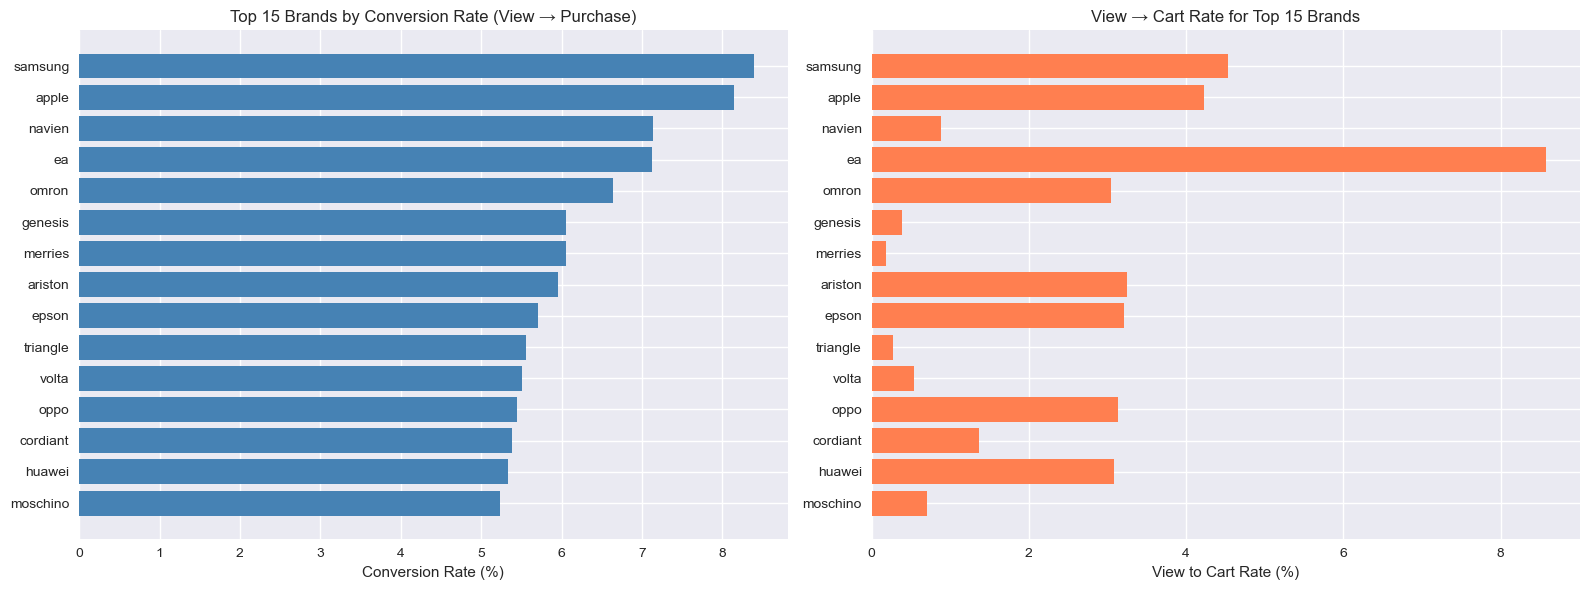

In [177]:
top15 = brand_funnel_clean.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Conversion rate
axes[0].barh(top15['brand'], top15['conversion_rate'], color='steelblue')
axes[0].set_title('Top 15 Brands by Conversion Rate (View → Purchase)')
axes[0].set_xlabel('Conversion Rate (%)')
axes[0].invert_yaxis()

# Plot 2 - View to cart rate
axes[1].barh(top15['brand'], top15['view_to_cart_rate'], color='coral')
axes[1].set_title('View → Cart Rate for Top 15 Brands')
axes[1].set_xlabel('View to Cart Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# Category Performance Analysis

In [178]:
df2_cat = df2[df2['category_code'].notna()].copy()

session_summary_cat = df2_cat.sort_values(['category_code', 'user_session', 'event_time'])

session_summary_cat = df2_cat.groupby(['category_code', 'user_session']).agg(
    user_id=('user_id', 'first'),
    event_type=('event_type', list),
    price=('price', 'sum')
).reset_index()

session_summary_cat['max_funnel_stage'] = session_summary_cat['event_type'].apply(get_max_funnel_stage)

cat_funnel_df = session_summary_cat.groupby('category_code').agg(
    total_sessions=('user_session', 'count'),
    cart_sessions=('max_funnel_stage', lambda x: (x == 'cart').sum()),
    purchase_sessions=('max_funnel_stage', lambda x: (x == 'purchase').sum())
).reset_index()

cat_funnel_df['conversion_rate'] = (
    cat_funnel_df['purchase_sessions'] / cat_funnel_df['total_sessions'] * 100
).round(2)

cat_funnel_df = cat_funnel_df[cat_funnel_df['total_sessions'] >= 100]
cat_funnel_df = cat_funnel_df.sort_values('conversion_rate', ascending=False)
cat_funnel_df.head(10)

,category_code,total_sessions,cart_sessions,purchase_sessions,conversion_rate
97,electronics.smartphone,3099337,148390,285252,9.20
30,appliances.iron,42646,1406,3489,8.18
26,appliances.environment.air_heater,30768,1015,2280,7.41
90,electronics.audio.headphone,372253,18113,27403,7.36
51,appliances.personal.scales,18001,598,1264,7.02
29,appliances.environment.water_heater,37166,1276,2593,6.98
42,appliances.kitchen.microwave,50401,1572,3519,6.98
101,electronics.video.tv,280610,11912,19221,6.85
48,appliances.kitchen.washer,217882,7428,14507,6.66
115,kids.fmcg.diapers,10852,41,710,6.54


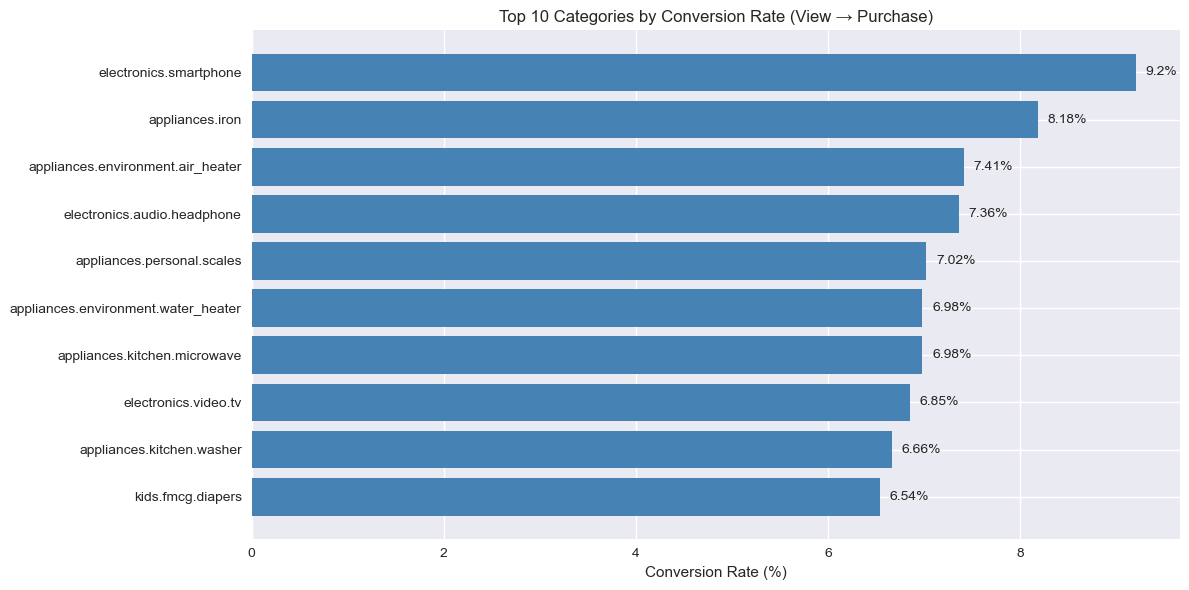

In [179]:
top10_cat = cat_funnel_df.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_cat['category_code'], top10_cat['conversion_rate'], color='steelblue')
plt.title('Top 10 Categories by Conversion Rate (View → Purchase)')
plt.xlabel('Conversion Rate (%)')
plt.gca().invert_yaxis()

# add value labels
for bar, val in zip(bars, top10_cat['conversion_rate']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{val}%', va='center')

plt.tight_layout()
plt.show()

# Time-Based Analysis

In [181]:
# Daily trends - using df which has date column already
daily_metrics = df.groupby('date').agg(
    daily_sessions=('user_session', 'nunique'),
    daily_users=('user_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

# Daily purchases from session_summary
daily_conversions = session_summary[session_summary['max_funnel_stage'] == 'purchase'].copy()
daily_conversions['date'] = daily_conversions['session_start'].dt.date
daily_conv_count = daily_conversions.groupby('date').size().reset_index(name='daily_purchases')

daily_metrics = daily_metrics.merge(daily_conv_count, on='date', how='left').fillna(0)
daily_metrics['conversion_rate'] = (daily_metrics['daily_purchases'] / daily_metrics['daily_sessions'] * 100).round(2)

daily_metrics.tail(10)

,date,daily_sessions,daily_users,revenue,daily_purchases,conversion_rate
21,2019-10-22,316706,223384,7913671.44,21280,6.72
22,2019-10-23,310453,219100,7614084.79,20974,6.76
23,2019-10-24,293587,206937,7470344.60,20292,6.91
24,2019-10-25,318055,223258,7235218.34,20301,6.38
25,2019-10-26,289579,202172,6917602.84,19351,6.68
26,2019-10-27,289835,201359,7197520.64,19859,6.85
27,2019-10-28,281001,195563,6591445.12,17914,6.38
28,2019-10-29,276723,193168,6432162.00,17347,6.27
29,2019-10-30,274906,191965,6633882.15,17702,6.44
30,2019-10-31,281446,198571,6455422.25,17313,6.15


In [182]:
hourly_sessions = df.groupby('hour').agg(
    hourly_sessions=('user_session', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

hourly_conversions = session_summary[session_summary['max_funnel_stage'] == 'purchase'].copy()
hourly_conversions['hour'] = hourly_conversions['session_start'].dt.hour
hourly_conv_count = hourly_conversions.groupby('hour').size().reset_index(name='hourly_purchases')

hourly_sessions = hourly_sessions.merge(hourly_conv_count, on='hour', how='left').fillna(0)
hourly_sessions['conversion_rate'] = (hourly_sessions['hourly_purchases'] / hourly_sessions['hourly_sessions'] * 100).round(2)

hourly_sessions.head(10)

,hour,hourly_sessions,revenue,hourly_purchases,conversion_rate
0,0,75459,980317.85,2551,3.38
1,1,148333,1577532.87,5241,3.53
2,2,275232,3873027.44,13164,4.78
3,3,392776,8696837.45,26844,6.83
4,4,483962,12064072.73,36356,7.51
5,5,534880,14398553.24,41726,7.80
6,6,573325,15808753.76,44634,7.79
7,7,592096,16338607.12,45714,7.72
8,8,603196,17058580.92,47356,7.85
9,9,585680,17551669.73,46327,7.91


In [183]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_sessions = df.groupby('day_of_week').agg(
    total_sessions=('user_session', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

dow_conversions = session_summary[session_summary['max_funnel_stage'] == 'purchase'].copy()
dow_conversions['day_of_week'] = dow_conversions['session_start'].dt.day_name()
dow_conv_count = dow_conversions.groupby('day_of_week').size().reset_index(name='purchases')

dow_sessions = dow_sessions.merge(dow_conv_count, on='day_of_week', how='left').fillna(0)
dow_sessions['conversion_rate'] = (dow_sessions['purchases'] / dow_sessions['total_sessions'] * 100).round(2)
dow_sessions['day_of_week'] = pd.Categorical(dow_sessions['day_of_week'], categories=day_order, ordered=True)
dow_sessions = dow_sessions.sort_values('day_of_week')

dow_sessions.head(10)

,day_of_week,total_sessions,revenue,purchases,conversion_rate
1,Monday,1173112,30158469.47,81531,6.95
5,Tuesday,1504737,36093986.02,96870,6.44
6,Wednesday,1476124,37064086.24,100906,6.84
4,Thursday,1413669,35850982.11,96474,6.82
0,Friday,1286835,31729266.61,87110,6.77
2,Saturday,1191891,29128868.23,81503,6.84
3,Sunday,1236041,29907553.95,85166,6.89


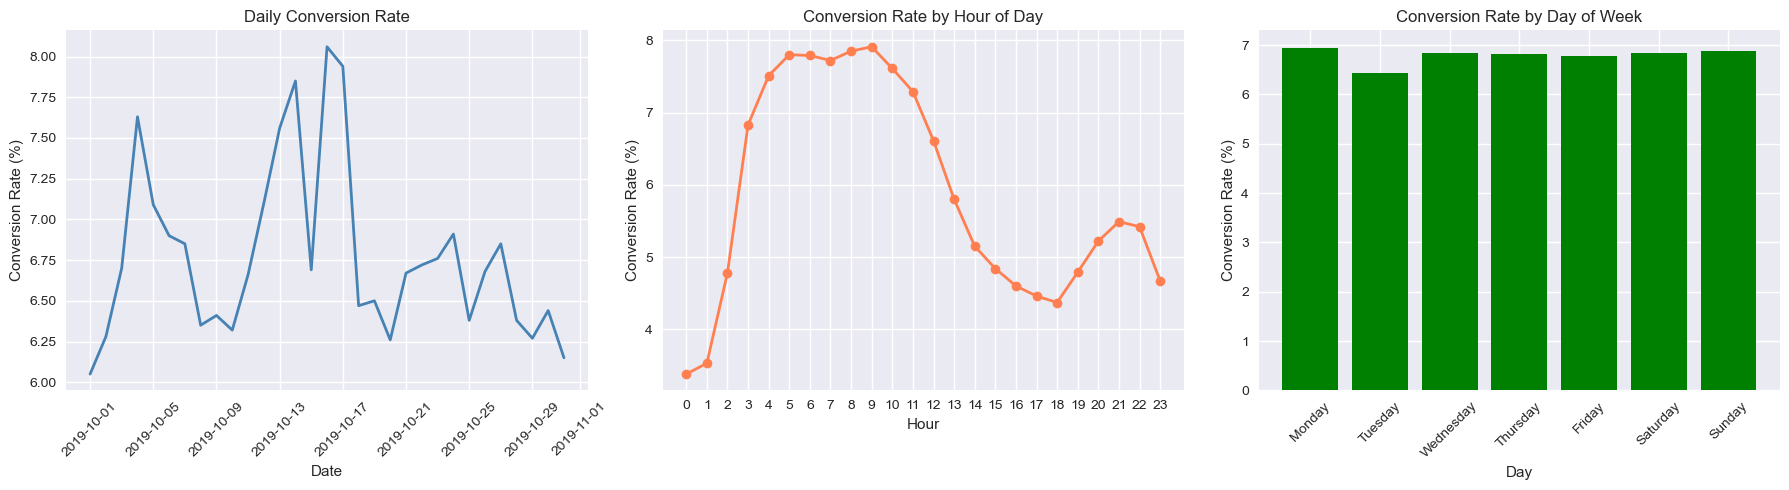

In [184]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Daily conversion rate
axes[0].plot(daily_metrics['date'], daily_metrics['conversion_rate'], color='steelblue', linewidth=2)
axes[0].set_title('Daily Conversion Rate')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Hourly conversion rate
axes[1].plot(hourly_sessions['hour'], hourly_sessions['conversion_rate'], color='coral', linewidth=2, marker='o')
axes[1].set_title('Conversion Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(0, 24))

# Day of week conversion rates
axes[2].bar(dow_sessions['day_of_week'], dow_sessions['conversion_rate'], color='green')
axes[2].set_title('Conversion Rate by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# KPI Summary

In [185]:
total_sessions = len(session_summary)
total_revenue = session_summary['price'].sum()
total_orders = len(session_summary[session_summary['max_funnel_stage'] == 'purchase'])
overall_cr = (total_orders / total_sessions * 100)

print(f"Overall Conversion Rate: {overall_cr:.2f}%")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Avg Order Value: ${total_revenue/total_orders:.2f}")
print(f"Total Sessions: {total_sessions:,}")
print(f"Total Orders: {total_orders:,}")

Overall Conversion Rate: 6.81%
Total Revenue: $229,933,212.63
Avg Order Value: $365.23
Total Sessions: 9,244,421
Total Orders: 629,560


# Exporting Results

In [186]:
daily_metrics.to_csv('daily_metrics.csv', index=False)
hourly_sessions.to_csv('hourly_sessions.csv', index=False)
dow_sessions.to_csv('dow_sessions.csv', index=False)
funnel_df.to_csv('overall_funnel.csv', index=False)
brand_funnel_clean.to_csv('brand_funnel.csv', index=False)
cat_funnel_df.to_csv('category_funnel.csv', index=False)
session_summary[['user_session','user_id','session_start','price','session_duration_sec','max_funnel_stage']].to_csv('session_summary.csv', index=False)

# Key Insights
### 1. Massive User Base with Low Funnel Progression
The dataset contains 3.02 million unique users and 9.24 million browsing sessions.
Despite high traffic volume, only a small percentage of sessions progressed beyond the product viewing stage.
### 2. Strong Drop-off Between View and Cart
Only 6.2% of sessions that viewed products reached the cart stage.
Approximately 93.8% of sessions dropped off before adding a product to cart, making this the largest leakage point in the customer journey.
### 3. Purchase Events Exceed Cart Events
Purchase sessions (629,560) exceeded cart sessions (573,097), which is unusual in a traditional e-commerce funnel.
This suggests the presence of:
Direct "Buy Now" purchases,
Purchases completed in different sessions,
Missing cart tracking events.
### 4. Significant Revenue Generated
Total revenue recorded during the month exceeded $229.9 million.
Average order value (AOV) was approximately $365, indicating relatively high-value transactions.
### 5. Smartphone Products Drive Conversions
The electronics.smartphone category achieved the highest conversion rate among major categories at approximately 9.2%.
Smartphones appear to be the strongest-performing product segment in terms of customer purchase intent.
### 6. Samsung and Apple Lead Brand Performance
Samsung and Apple generated the highest number of purchase sessions among brands with substantial traffic.
Both brands maintained conversion rates above 8%, outperforming many competitors.
### 7. User-Level Funnel Shows Similar Behavior
At the user level, approximately 11.5% of users eventually completed a purchase.
However, nearly 89% of users never progressed beyond the viewing stage.
### 8. Purchase Sessions Tend to Have Longer Engagement
Sessions reaching the purchase stage generally exhibited longer durations than view-only sessions.
This indicates that users who spend more time exploring products are more likely to convert.

---

# Business Recommendations

1. Optimize the **View → Cart** stage by improving product pages, adding clearer call-to-action buttons, and highlighting promotions to encourage more users to add products to their carts.

2. Investigate the **purchase sessions without corresponding cart events**. This may indicate the presence of direct "Buy Now" functionality or missing cart tracking events. Verifying the event tracking pipeline will improve the accuracy of future funnel analyses.

3. Analyze the brands and product categories with the highest conversion rates and use these insights to optimize lower-performing products through better merchandising and targeted marketing.

4. Monitor funnel performance over time using key metrics such as View-to-Cart Conversion Rate, Cart-to-Purchase Conversion Rate, and Overall Funnel Conversion Rate to identify changes in customer behavior and measure the impact of business initiatives.

5. Use customer segmentation and personalized marketing campaigns to improve conversion rates and encourage users who abandon the funnel to complete their purchases.

---

# Conclusion

This funnel analysis examined customer behavior across the **View → Cart → Purchase** journey to identify conversion patterns and opportunities for optimization. The analysis revealed significant drop-offs throughout the funnel and identified an unusual pattern where purchase sessions exceeded cart sessions, suggesting the presence of direct purchase flows or incomplete cart event tracking.

Overall, the findings demonstrate the importance of continuously monitoring customer journeys, improving the shopping experience, and ensuring accurate event tracking. By optimizing funnel performance and reducing customer drop-offs, businesses can improve conversion rates, increase revenue, and enhance the overall customer experience.
